  wav    elem   EP   c2    A      B     C   
-------- ---- ----- --- ------- ----- ------
6439.813 20.0 2.526 1.0  -6.968 5.068 -1.288
6456.337 20.0 2.523 1.0  -7.372 4.664 -1.692
6494.525 20.0 2.521 1.0  -7.186  4.85 -1.506
6499.682 20.0 2.523 1.0  -7.395 4.641 -1.715
6718.451 20.0 2.709 1.0  -7.098 4.938 -1.418
6605.139 21.1   1.5 1.0 -11.817 0.219 -2.947
4759.808 22.0 2.256 1.0  -9.328 2.708 -2.308
4723.141 22.0 1.053 1.0  -8.903 3.133 -1.883
 4742.07 22.0 2.236 1.0  -7.851 4.185 -0.831
6554.393 22.0 1.443 1.0  -8.414 3.622 -1.394
     ...  ...   ... ...     ...   ...    ...
4754.578 28.0 3.635 1.0  -6.039 5.997 -0.249
4757.057 28.0  3.48 1.0  -7.874 4.162 -2.084
6005.018 28.0 1.676 1.0  -8.223 3.813 -2.433
6085.938 28.0 4.266 1.0  -7.101 4.935 -1.311
6108.811 28.0 1.676 1.0  -7.761 4.275 -1.971
6482.628 28.0 1.935 1.0  -7.282 4.754 -1.492
 6538.11 28.0 1.935 1.0  -7.285 4.751 -1.495
6644.385 28.0 1.676 1.0  -7.384 4.652 -1.594
6768.549 28.0 1.826 1.0  -7.634 4.402 -1.844
4722.692 3

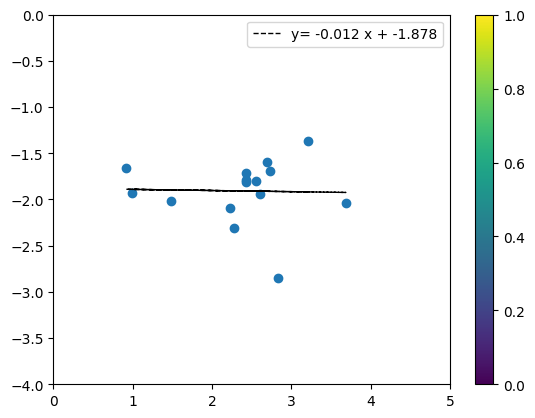

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from scipy.optimize import curve_fit

def func(x, a, b):
    return b +a*x


plt.figure()

t2 = Table.read('samanta4500.out',format='ascii')
print(t2)

x=t2['EP'] #energ. minima 
y=t2['C']  #abbondanze calcolata
fe=t2['elem'] 

#z=t2['D'] #EW


#z>20

#limit=(fe==26.0) #elimino righe troppo sature e molto piccole e scelgo le righe del ferro I
#26.0=Fe I, 26.1=Fe II, 28.0=Ni I, 20.0=Ca I, 22.1=Ti II, 21.1=Sc II, 25.0=Mn I, 12.0=Mg I
limit=(fe==26.0)
x=x[limit]
y=y[limit]


limit=((y<np.mean(y)+2*np.std(y))&(y>np.mean(y)-2*np.std(y))) #elimino righe oltre 2 sigma 
x=x[limit]
y=y[limit]



print(np.mean(y),np.std(y))

plt.scatter(x,y) #plotto il grafico 


popt, pcov = curve_fit(func, x, y,method='lm') #calcolo parametri della interpolazione lineare
plt.plot(x, func(x, *popt), 'k--', lw=1., label='y= %5.3f x + %5.3f'% tuple(popt)) #plotto la interpolazione linerare
std1=np.std(y-(func(x,*popt))) #calcolo la sd della differenza dalla interpolazione lineare
print(std1)  


plt.axis([0,5,-4,0]) #definisco i limiti del grafico
plt.colorbar()   
plt.legend()
plt.show()


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from scipy.optimize import curve_fit

def func(x, a, b):
    return b + a*x

plt.figure()

t2 = Table.read('samanta4500.out', format='ascii')
print("This is z")
print(z)
x  = t2['EP']        # energia minima
y  = t2['C'] # abbondanza calcolata
#print(t2['wav'])
#print(fe)
fe = t2['elem']      # specie
#z  = 10**t2['c2']    # EW in mÅ (assumendo c2 = log10(EW[mÅ]))
print(z)
# --- Fe I + EW > 20 mÅ ---
limit = (fe == 26.0)
z = (10**t2['c2'])
z>20
x = x[limit]

y = y[limit]
cvals = z[limit]
#cvals = cvals[limit]  # keep colors aligned with the same mask

print(np.mean(y), np.std(y))

# use EW as color
sc = plt.scatter(x, y, c=cvals, cmap='viridis')
cbar = plt.colorbar(sc)
cbar.set_label('EW [mÅ]')

popt, pcov = curve_fit(func, x, y, method='lm')
plt.plot(x, func(x, *popt), 'k--', lw=1.,
         label='y= %5.3f x + %5.3f' % tuple(popt))
std1 = np.std(y - func(x, *popt))
print(std1)

plt.axis([0, 5, -4, 0])
plt.legend()
plt.show()

This is z


NameError: name 'z' is not defined

<Figure size 640x480 with 0 Axes>

In [5]:
print(y)

  C   
------
-1.827
-0.249
-2.084
-2.433
-1.311
-1.971
-1.492
-1.495
-1.594
-1.844


  EP 
-----
 3.38
3.635
 3.48
1.676
4.266
1.676
1.935
1.935
1.676
1.826
  C   
------
 0.741
-1.827
-0.249
-2.084
-2.433
-1.311
-1.971
-1.492
-1.495
-1.594
-1.844
-1.7834444444444446 0.33002192220487786
0.31792217564618974
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


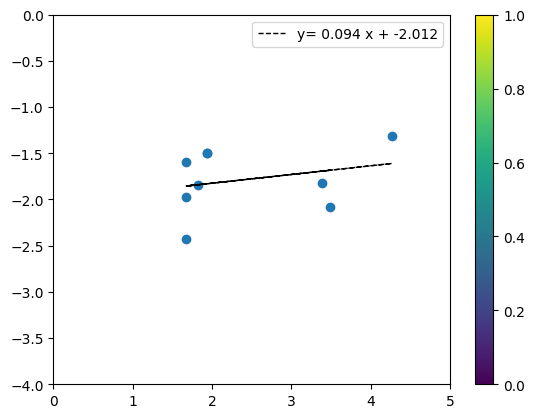

In [12]:
def func(x, a, b):
    return b +a*x


plt.figure()

t2 = Table.read('samanta4500.out',format='ascii')

x=t2['EP'] #energ. minima 
y=t2['C']  #abbondanze calcolata
y[np.arange(len(y)) != 1]
fe=t2['elem'] 
#z=t2['D'] #EW


z=100

limit=(fe==28.0) #nickel
x=x[limit]
y=y[limit]

x= x[np.arange(len(x)) != 0]
print(x)
print(y)
y= y[np.arange(len(y)) != 0]
limit=((y<np.mean(y)+2*np.std(y))&(y>np.mean(y)-2*np.std(y))) #elimino righe oltre 2 sigma 
x=x[limit]
y=y[limit]



print(np.mean(y),np.std(y))

plt.scatter(x,y) #plotto il grafico 


popt, pcov = curve_fit(func, x, y,method='lm') #calcolo parametri della interpolazione lineare
plt.plot(x, func(x, *popt), 'k--', lw=1., label='y= %5.3f x + %5.3f'% tuple(popt)) #plotto la interpolazione linerare
std1=np.std(y-(func(x,*popt))) #calcolo la sd della differenza dalla interpolazione lineare
print(std1)  


plt.axis([0,5,-4,0]) #definisco i limiti del grafico
plt.colorbar()   
plt.legend()
plt.show()


-1.032 0.22632984778857607
0.22215331616572045
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


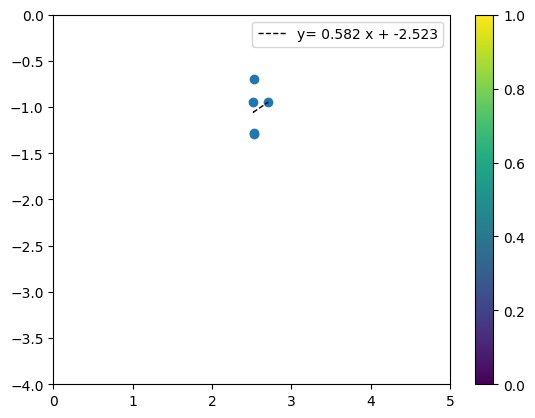

In [13]:
def func(x, a, b):
    return b +a*x


plt.figure()

t2 = Table.read('samanta5000.out',format='ascii')

x=t2['EP'] #energ. minima 
y=t2['C']  #abbondanze calcolata
fe=t2['elem'] 
#z=t2['D'] #EW


z=100

limit=(fe==20.0) #nickel
x=x[limit]
y=y[limit]


limit=((y<np.mean(y)+2*np.std(y))&(y>np.mean(y)-2*np.std(y))) #elimino righe oltre 2 sigma 
x=x[limit]
y=y[limit]



print(np.mean(y),np.std(y))

plt.scatter(x,y) #plotto il grafico 


popt, pcov = curve_fit(func, x, y,method='lm') #calcolo parametri della interpolazione lineare
plt.plot(x, func(x, *popt), 'k--', lw=1., label='y= %5.3f x + %5.3f'% tuple(popt)) #plotto la interpolazione linerare
std1=np.std(y-(func(x,*popt))) #calcolo la sd della differenza dalla interpolazione lineare
print(std1)  


plt.axis([0,5,-4,0]) #definisco i limiti del grafico
plt.colorbar()   
plt.legend()
plt.show()


-1.015 0.5708808982616252
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
0.5708607216948188


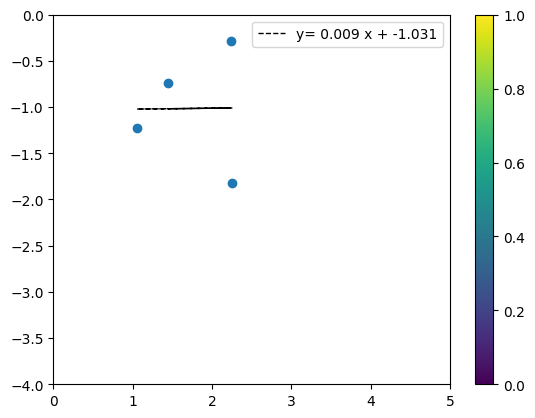

In [14]:
def func(x, a, b):
    return b +a*x


plt.figure()

t2 = Table.read('samanta5000.out',format='ascii')

x=t2['EP'] #energ. minima 
y=t2['C']  #abbondanze calcolata
fe=t2['elem'] 
#z=t2['D'] #EW


z=100

limit=(fe==22.0) #titanium
x=x[limit]
y=y[limit]


limit=((y<np.mean(y)+2*np.std(y))&(y>np.mean(y)-2*np.std(y))) #elimino righe oltre 2 sigma 
x=x[limit]
y=y[limit]



print(np.mean(y),np.std(y))

plt.scatter(x,y) #plotto il grafico 


popt, pcov = curve_fit(func, x, y,method='lm') #calcolo parametri della interpolazione lineare
plt.plot(x, func(x, *popt), 'k--', lw=1., label='y= %5.3f x + %5.3f'% tuple(popt)) #plotto la interpolazione linerare
std1=np.std(y-(func(x,*popt))) #calcolo la sd della differenza dalla interpolazione lineare
print(std1)  


plt.axis([0,5,-4,0]) #definisco i limiti del grafico
plt.colorbar()   
plt.legend()
plt.show()


Mean abundance: -1.1947333333333332 Std: 0.4016307535812244
Scatter around fit: 0.38814512721791755
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


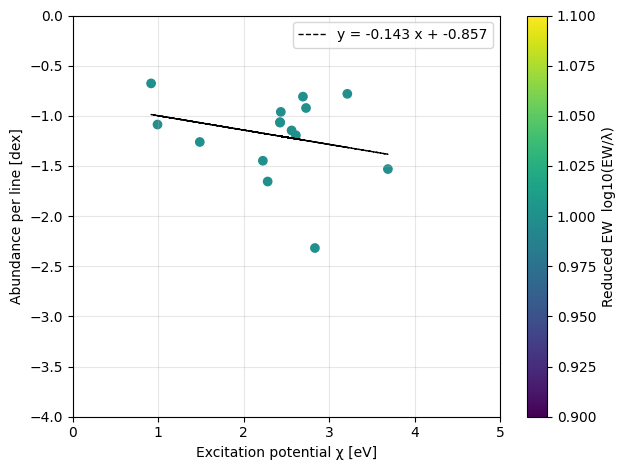

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from scipy.optimize import curve_fit

def func(x, a, b):
    return b + a*x

plt.figure()

t2 = Table.read('samanta5000.out', format='ascii')

x = t2['EP']     # excitation potential
y = t2['C']      # abundance
fe = t2['elem']  # species labels
wav = np.array(t2['wav'], float)
c2  = np.array(t2['c2'], float)   # reduced EW = log10(EW/λ)

# --- choose which "color" to display ---
use_reduced = True   # set False if you want actual EW in mÅ

if use_reduced:
    z = c2
    cbar_label = "Reduced EW  log10(EW/λ)"
else:
    EW_A  = (10.0**c2) * wav        # EW in Å
    EW_mA = EW_A * 1000.0           # convert to mÅ
    z = EW_mA
    cbar_label = "Equivalent width [mÅ]"

# --- keep only Fe I lines (26.0) ---
mask = (fe == 26.0)
x, y, z = x[mask], y[mask], z[mask]

# --- sigma clipping to drop outliers ---
mask2 = ((y < np.mean(y)+2*np.std(y)) & (y > np.mean(y)-2*np.std(y)))
x, y, z = x[mask2], y[mask2], z[mask2]

print("Mean abundance:", np.mean(y), "Std:", np.std(y))

# --- plot with colorbar ---
sc = plt.scatter(x, y, c=z, cmap='viridis')
cbar = plt.colorbar(sc)
cbar.set_label(cbar_label)

# --- linear fit ---
popt, pcov = curve_fit(func, x, y, method='lm')
plt.plot(x, func(x, *popt), 'k--', lw=1.,
         label='y = %5.3f x + %5.3f' % tuple(popt))
std1 = np.std(y - func(x, *popt))
print("Scatter around fit:", std1)

plt.axis([0, 5, -4, 0])
plt.legend()
plt.xlabel("Excitation potential χ [eV]")
plt.ylabel("Abundance per line [dex]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [30]:

from matplotlib.colors import Normalize
print(t2.colnames)

['wav', 'elem', 'EP', 'c2', 'A', 'B', 'C']


## Iron

N lines: 15
wav range [Å]: 4737.315 → 6750.927
Reduced EW range: -5.829363411844755 → -5.675532263388176
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


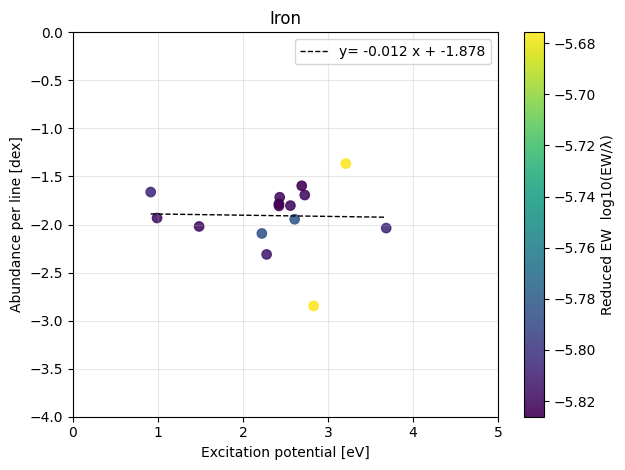

In [69]:
def func(x, a, b):
    return b + a*x

t2 = Table.read('samanta4500.out', format='ascii')

x   = np.array(t2['EP'], float)      # excitation potential [eV]
y   = np.array(t2['C'],  float)      # abundance [dex]
fe  = t2['elem']                     # species (numeric 26.0 or string 'Fe I')
wav = np.array(t2['wav'], float)     # wavelength [Å]
c2  = np.array(t2['c2'],  float)

# --- keep only Fe I ---
try:
    mask = (fe == 26.0)
    if mask.sum() == 0:
        mask = (np.char.strip(fe.astype(str)) == 'Fe I')
except Exception:
    mask = (np.char.strip(fe.astype(str)) == 'Fe I')

x, y, wav, c2 = x[mask], y[mask], wav[mask], c2[mask]

# --- compute three diagnostics ---
# Option A: if c2 is reduced EW already (rare in your case)
rw_A = c2                                  # supposed log10(EW/λ)

# Option B: if c2 is log10(EW[mÅ])  --> reduced EW = c2 - 3 - log10(λ[Å])
rw_B = c2 - 3.0 - np.log10(wav)

# Actual EW in mÅ if c2 = log10(EW[mÅ])
EW_mA_from_c2 = 10.0**c2                   # only valid if c2 = log10(EW[mÅ])

# --- pick the sensible one for coloring ---
# Reduced EW should be around -6 .. -4 typically.
use_rw = rw_A if (-7 < np.nanmedian(rw_A) < -3) else rw_B
z = use_rw
cbar_label = "Reduced EW  log10(EW/λ)"

# --- mild sigma-clipping on y (abundance) ---
m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
m &= (y > np.nanmean(y)-2*np.nanstd(y)) & (y < np.nanmean(y)+2*np.nanstd(y))
x, y, z = x[m], y[m], z[m]

print("N lines:", len(x))
print("wav range [Å]:", np.nanmin(wav[m]), "→", np.nanmax(wav[m]))
print("Reduced EW range:", np.nanmin(z), "→", np.nanmax(z))

# --- plot with colorbar; tighten colora range to show contrast if dynamic range is small ---
vmin, vmax = np.percentile(z, [5, 95]) if len(z) > 5 else (np.nanmin(z), np.nanmax(z))
sc = plt.scatter(x, y, c=z, cmap='viridis', s=45, alpha=0.9, norm=Normalize(vmin=vmin, vmax=vmax))
cbar = plt.colorbar(sc)
cbar.set_label(cbar_label)

# Fit
popt, _ = curve_fit(func, x, y, method='lm')
xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
plt.plot(xx, func(xx, *popt), 'k--', lw=1., label='y= %5.3f x + %5.3f' % tuple(popt))

plt.axis([0, 5, -4, 0])
plt.title("Iron")
plt.xlabel("Excitation potential [eV]")
plt.ylabel("Abundance per line [dex]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

This is z
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
-1.76775 0.6307413792514329
0.6306954427089414
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


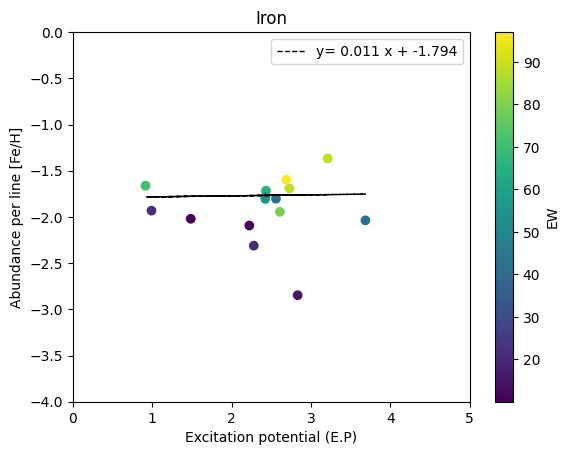

In [18]:
plt.figure()

t2 = Table.read('samanta4500.out', format='ascii')
print("This is z")
print(z)
x  = t2['EP']        # energia minima
y  = t2['C'] # abbondanza calcolata
#print(t2['wav'])
#print(fe)
fe = t2['elem']      # specie
ew = [88.56,14.92,79.07, 10.98,70.8,40.87, 68.09,20.77,21.69,10.02,88.58,65.09,40.65,59.62,97.02,54.29]
#z  = 10**t2['c2']    # EW in mÅ (assumendo c2 = log10(EW[mÅ]))
print(z)
# --- Fe I + EW > 20 mÅ ---
limit = (fe == 26.0)
z = (10**t2['c2'])
z>20
x = x[limit]

y = y[limit]
cvals = ew
#cvals = cvals[limit]  # keep colors aligned with the same mask

print(np.mean(y), np.std(y))

# use EW as color
sc = plt.scatter(x, y, c=cvals, cmap='viridis')
cbar = plt.colorbar(sc)
cbar.set_label('EW')

popt, pcov = curve_fit(func, x, y, method='lm')
plt.plot(x, func(x, *popt), 'k--', lw=1.,
         label='y= %5.3f x + %5.3f' % tuple(popt))
std1 = np.std(y - func(x, *popt))
print(std1)
plt.title("Iron")
plt.axis([0, 5, -4, 0])
plt.xlabel("Excitation potential (E.P)")
plt.ylabel("Abundance per line [Fe/H]")
plt.legend()
plt.show()

## Calcio

N lines: 5
wav range [Å]: 6439.813 → 6718.451
Reduced EW range: -5.827269154051204 → -5.8088732564518555
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


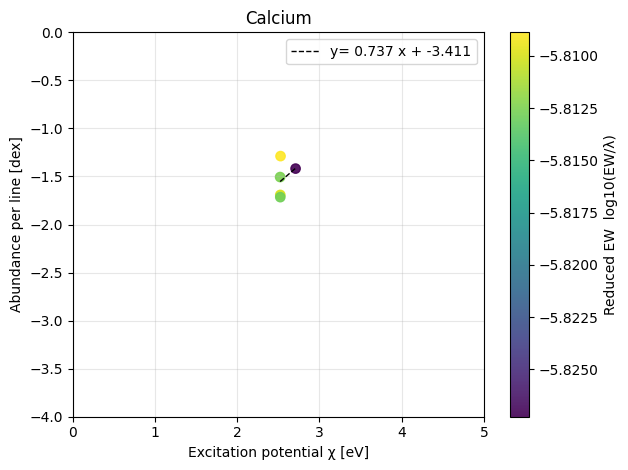

In [70]:
def func(x, a, b):
    return b + a*x

t2 = Table.read('samanta4500.out', format='ascii')

x   = np.array(t2['EP'], float)      # excitation potential [eV]
y   = np.array(t2['C'],  float)      # abundance [dex]
fe  = t2['elem']                     # species (numeric 26.0 or string 'Fe I')
wav = np.array(t2['wav'], float)     # wavelength [Å]
c2  = np.array(t2['c2'],  float)

# --- keep only Ni ---
try:
    mask = (fe == 20.0)
    if mask.sum() == 0:
        mask = (np.char.strip(fe.astype(str)) == 'Ca')
except Exception:
    mask = (np.char.strip(fe.astype(str)) == 'Ca')

x, y, wav, c2 = x[mask], y[mask], wav[mask], c2[mask]

# --- compute three diagnostics ---
# Option A: if c2 is reduced EW already (rare in your case)
rw_A = c2                                  # supposed log10(EW/λ)

# Option B: if c2 is log10(EW[mÅ])  --> reduced EW = c2 - 3 - log10(λ[Å])
rw_B = c2 - 3.0 - np.log10(wav)

# Actual EW in mÅ if c2 = log10(EW[mÅ])
EW_mA_from_c2 = 10.0**c2                   # only valid if c2 = log10(EW[mÅ])

# --- pick the sensible one for coloring ---
# Reduced EW should be around -6 .. -4 typically.
use_rw = rw_A if (-7 < np.nanmedian(rw_A) < -3) else rw_B
z = use_rw
cbar_label = "Reduced EW  log10(EW/λ)"

# --- mild sigma-clipping on y (abundance) ---
m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
m &= (y > np.nanmean(y)-2*np.nanstd(y)) & (y < np.nanmean(y)+2*np.nanstd(y))
x, y, z = x[m], y[m], z[m]

print("N lines:", len(x))
print("wav range [Å]:", np.nanmin(wav[m]), "→", np.nanmax(wav[m]))
print("Reduced EW range:", np.nanmin(z), "→", np.nanmax(z))

# --- plot with colorbar; tighten color range to show contrast if dynamic range is small ---
vmin, vmax = np.percentile(z, [5, 95]) if len(z) > 5 else (np.nanmin(z), np.nanmax(z))
sc = plt.scatter(x, y, c=z, cmap='viridis', s=45, alpha=0.9, norm=Normalize(vmin=vmin, vmax=vmax))
cbar = plt.colorbar(sc)
cbar.set_label(cbar_label)

# Fit
popt, _ = curve_fit(func, x, y, method='lm')
xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
plt.plot(xx, func(xx, *popt), 'k--', lw=1., label='y= %5.3f x + %5.3f' % tuple(popt))

plt.axis([0, 5, -4, 0])
plt.xlabel("Excitation potential χ [eV]")
plt.ylabel("Abundance per line [dex]")
plt.title("Calcium")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

This is z
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False]
-1.032 0.22632984778857607
0.22215331616572045
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


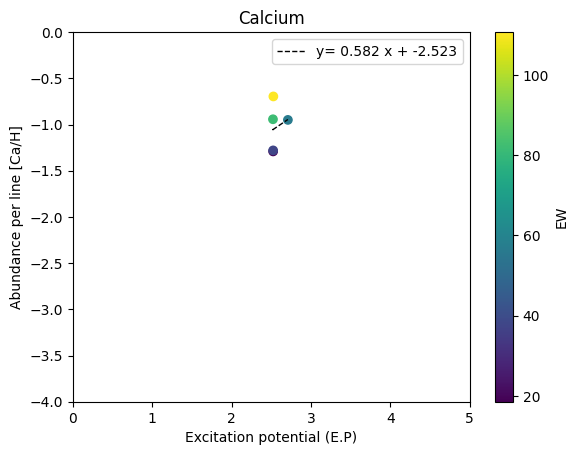

In [57]:
plt.figure()

t2 = Table.read('samanta5000.out', format='ascii')
print("This is z")
print(z)
x  = t2['EP']        # energia minima
y  = t2['C'] # abbondanza calcolata
#print(t2['wav'])
#print(fe)
fe = t2['elem']      # specie
#z  = 10**t2['c2']    # EW in mÅ (assumendo c2 = log10(EW[mÅ]))
ew = [110.7, 18.54, 81.64, 37.76, 56.69]
# --- Fe I + EW > 20 mÅ ---
limit = (fe == 20.0)
z = (10**t2['c2'])
print(z>20)
x = x[limit]

y = y[limit]
cvals = ew
#cvals = cvals[limit]  # keep colors aligned with the same mask

print(np.mean(y), np.std(y))

# use EW as color
sc = plt.scatter(x, y, c=cvals, cmap='viridis')
cbar = plt.colorbar(sc)
cbar.set_label('EW')

popt, pcov = curve_fit(func, x, y, method='lm')
plt.plot(x, func(x, *popt), 'k--', lw=1.,
         label='y= %5.3f x + %5.3f' % tuple(popt))
std1 = np.std(y - func(x, *popt))
print(std1)
plt.title("Calcium")
plt.axis([0, 5, -4, 0])

plt.xlabel("Excitation potential (E.P)")
plt.ylabel("Abundance per line [Ca/H]")
plt.legend()
plt.show()

## Nickel

N lines: 10
wav range [Å]: 4714.955 → 6768.549
Reduced EW range: -5.830495577276951 → -5.673477552143348
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


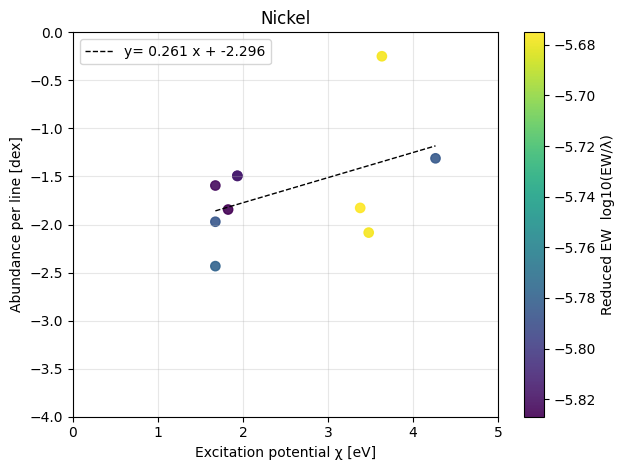

In [71]:
def func(x, a, b):
    return b + a*x

t2 = Table.read('samanta4500.out', format='ascii')

x   = np.array(t2['EP'], float)      # excitation potential [eV]
y   = np.array(t2['C'],  float)      # abundance [dex]
fe  = t2['elem']                     # species (numeric 26.0 or string 'Fe I')
wav = np.array(t2['wav'], float)     # wavelength [Å]
c2  = np.array(t2['c2'],  float)

# --- keep only Ni --- #22.1=Ti II, 21.1=Sc II, 25.0=Mn I, 12.0=Mg
try:
    mask = (fe == 28)
    if mask.sum() == 0:
        mask = (np.char.strip(fe.astype(str)) == 'Ni')
except Exception:
    mask = (np.char.strip(fe.astype(str)) == 'Ni')

x, y, wav, c2 = x[mask], y[mask], wav[mask], c2[mask]

# --- compute three diagnostics ---
# Option A: if c2 is reduced EW already (rare in your case)
rw_A = c2                                  # supposed log10(EW/λ)

# Option B: if c2 is log10(EW[mÅ])  --> reduced EW = c2 - 3 - log10(λ[Å])
rw_B = c2 - 3.0 - np.log10(wav)

# Actual EW in mÅ if c2 = log10(EW[mÅ])
EW_mA_from_c2 = 10.0**c2                   # only valid if c2 = log10(EW[mÅ])

# --- pick the sensible one for coloring ---
# Reduced EW should be around -6 .. -4 typically.
use_rw = rw_A if (-7 < np.nanmedian(rw_A) < -3) else rw_B
z = use_rw
cbar_label = "Reduced EW  log10(EW/λ)"

# --- mild sigma-clipping on y (abundance) ---
m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
m &= (y > np.nanmean(y)-2*np.nanstd(y)) & (y < np.nanmean(y)+2*np.nanstd(y))
x, y, z = x[m], y[m], z[m]

print("N lines:", len(x))
print("wav range [Å]:", np.nanmin(wav[m]), "→", np.nanmax(wav[m]))
print("Reduced EW range:", np.nanmin(z), "→", np.nanmax(z))

# --- plot with colorbar; tighten color range to show contrast if dynamic range is small ---
vmin, vmax = np.percentile(z, [5, 95]) if len(z) > 5 else (np.nanmin(z), np.nanmax(z))
sc = plt.scatter(x, y, c=z, cmap='viridis', s=45, alpha=0.9, norm=Normalize(vmin=vmin, vmax=vmax))
cbar = plt.colorbar(sc)
cbar.set_label(cbar_label)

# Fit
popt, _ = curve_fit(func, x, y, method='lm')
xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
plt.plot(xx, func(xx, *popt), 'k--', lw=1., label='y= %5.3f x + %5.3f' % tuple(popt))

plt.axis([0, 5, -4, 0])
plt.title("Nickel")
plt.xlabel("Excitation potential χ [eV]")
plt.ylabel("Abundance per line [dex]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

[ 0.741 -1.827 -0.249 -2.084 -2.433 -1.311 -1.971 -1.492 -1.495 -1.594
 -1.844]
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


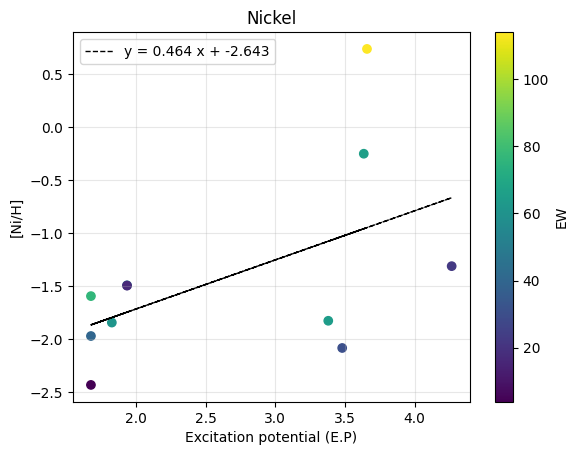

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.optimize import curve_fit

t2 = Table.read("samanta4500.out", format="ascii")

# Your EW values (for Nickel lines only)
ew_subset = np.array([114.1, 64.26, 65.56, 30.74, 3.858, 
                      22.5, 39.71, 47.08, 16.36, 76.36, 61.53])

# 1) Add a new column full of NaN
t2['EW_mA'] = np.full(len(t2), np.nan)

# 2) Fill only the Nickel rows (elem == 28)
mask_Ni = (t2['elem'] == 28.0)
t2['EW_mA'][mask_Ni] = ew_subset

# 3) Select the rows for plotting
x = np.array(t2['EP'][mask_Ni])
#x=x[1:]
y = np.array(t2['C'][mask_Ni])

#y=y[1:]
print(y)
cvals = np.array(t2['EW_mA'][mask_Ni])
#cvals=cvals[1:]
# 4) Fit a line
def func(u,a,b): return a*u+b
popt,_ = curve_fit(func, x, y, method='lm')

# 5) Scatter plot with EW as color
sc = plt.scatter(x, y, c=cvals, cmap="viridis")
plt.colorbar(sc, label="EW")

plt.plot(x, func(x,*popt), "k--", lw=1, 
         label=f"y = {popt[0]:.3f} x + {popt[1]:.3f}")
plt.title("Nickel"); plt.xlabel("Excitation potential (E.P)"); plt.ylabel("[Ni/H]")
plt.axis(); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


## Titanium 22


[-2.308 -1.883 -0.831 -1.394]
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


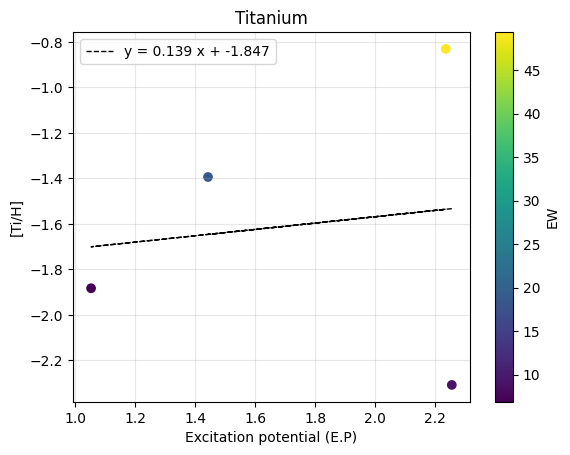

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.optimize import curve_fit

t2 = Table.read("samanta4500.out", format="ascii")

# Your EW values (for Titanium lines only)
ew_subset = np.array([9.095, 6.875, 49.37, 18.26])

# 1) Add a new column full of NaN
t2['EW_mA'] = np.full(len(t2), np.nan)

# 2) Fill only the Nickel rows (elem == 28)
mask_Ti = (t2['elem'] == 22.0)
t2['EW_mA'][mask_Ti] = ew_subset

# 3) Select the rows for plotting
x = np.array(t2['EP'][mask_Ti])

y = np.array(t2['C'][mask_Ti])


print(y)
cvals = np.array(t2['EW_mA'][mask_Ti])

# 4) Fit a line
def func(u,a,b): return a*u+b
popt,_ = curve_fit(func, x, y, method='lm')

# 5) Scatter plot with EW as color
sc = plt.scatter(x, y, c=cvals, cmap="viridis")
plt.colorbar(sc, label="EW")

plt.plot(x, func(x,*popt), "k--", lw=1, 
         label=f"y = {popt[0]:.3f} x + {popt[1]:.3f}")
plt.title("Titanium"); plt.xlabel("Excitation potential (E.P)"); plt.ylabel("[Ti/H]")
plt.axis(); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


This is z
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False]
-1.015 0.5708808982616252
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
0.5708607216948188


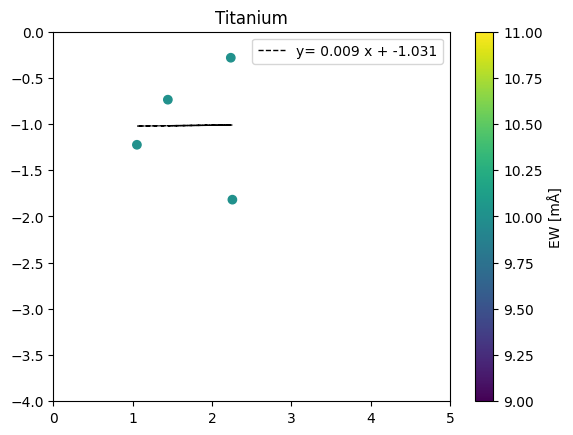

In [135]:
plt.figure()

t2 = Table.read('samanta5000.out', format='ascii')
print("This is z")
print(z)
x  = t2['EP']        # energia minima
y  = t2['C'] # abbondanza calcolata
#print(t2['wav'])
#print(fe)
fe = t2['elem']      # specie
#z  = 10**t2['c2']    # EW in mÅ (assumendo c2 = log10(EW[mÅ]))
print(z)
# --- Fe I + EW > 20 mÅ ---
limit = (fe == 22.0)
z = (10**t2['c2'])
print(z>20)
x = x[limit]

y = y[limit]
cvals = z[limit]
#cvals = cvals[limit]  # keep colors aligned with the same mask

print(np.mean(y), np.std(y))

# use EW as color
sc = plt.scatter(x, y, c=cvals, cmap='viridis')
cbar = plt.colorbar(sc)
cbar.set_label('EW [mÅ]')

popt, pcov = curve_fit(func, x, y, method='lm')
plt.plot(x, func(x, *popt), 'k--', lw=1.,
         label='y= %5.3f x + %5.3f' % tuple(popt))
std1 = np.std(y - func(x, *popt))
print(std1)
plt.title("Titanium")
plt.axis([0, 5, -4, 0])
plt.legend()
plt.show()

## V 23

[ 0.101 -2.807]
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/var/folders/6y/fwk8pnpn3l1_063t_xyj4ws80000gn/T/ipykernel_83000/1559993743.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt,_ = curve_fit(func, x, y, method='lm')


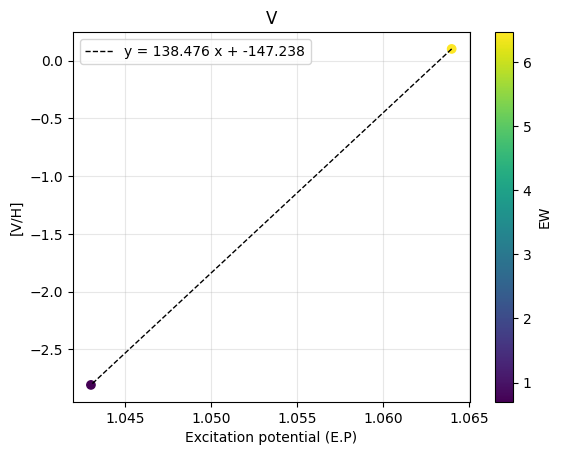

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.optimize import curve_fit

t2 = Table.read("samanta4500.out", format="ascii")

# Your EW values (for Titanium lines only)
ew_subset = np.array([6.465, 0.701])

# 1) Add a new column full of NaN
t2['EW_mA'] = np.full(len(t2), np.nan)

# 2) Fill only the Nickel rows (elem == 28)
mask_Ti = (t2['elem'] == 23.0)
t2['EW_mA'][mask_Ti] = ew_subset

# 3) Select the rows for plotting
x = np.array(t2['EP'][mask_Ti])

y = np.array(t2['C'][mask_Ti])


print(y)
cvals = np.array(t2['EW_mA'][mask_Ti])

# 4) Fit a line
def func(u,a,b): return a*u+b
popt,_ = curve_fit(func, x, y, method='lm')

# 5) Scatter plot with EW as color
sc = plt.scatter(x, y, c=cvals, cmap="viridis")
plt.colorbar(sc, label="EW")

plt.plot(x, func(x,*popt), "k--", lw=1, 
         label=f"y = {popt[0]:.3f} x + {popt[1]:.3f}")
plt.title("V"); plt.xlabel("Excitation potential (E.P)"); plt.ylabel("[V/H]")
plt.axis(); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


This is z
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False]
-0.662 1.4540000000000002
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
7.66053886991358e-15


/var/folders/6y/fwk8pnpn3l1_063t_xyj4ws80000gn/T/ipykernel_14192/3477039892.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, x, y, method='lm')


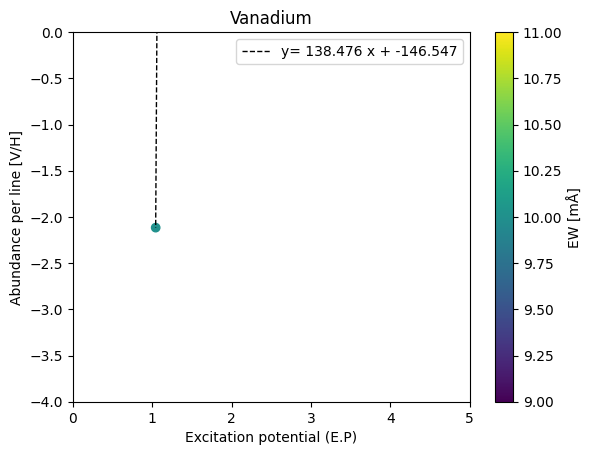

In [136]:
plt.figure()

t2 = Table.read('samanta5000.out', format='ascii')
print("This is z")
print(z)
x  = t2['EP']        # energia minima
y  = t2['C'] # abbondanza calcolata
#print(t2['wav'])
#print(fe)
fe = t2['elem']      # specie
#z  = 10**t2['c2']    # EW in mÅ (assumendo c2 = log10(EW[mÅ]))
print(z)
# --- Fe I + EW > 20 mÅ ---
limit = (fe == 23.0)
z = (10**t2['c2'])
print(z>20)
x = x[limit]

y = y[limit]
cvals = z[limit]
#cvals = cvals[limit]  # keep colors aligned with the same mask

print(np.mean(y), np.std(y))

# use EW as color
sc = plt.scatter(x, y, c=cvals, cmap='viridis')
cbar = plt.colorbar(sc)
cbar.set_label('EW [mÅ]')

popt, pcov = curve_fit(func, x, y, method='lm')
plt.plot(x, func(x, *popt), 'k--', lw=1.,
         label='y= %5.3f x + %5.3f' % tuple(popt))
std1 = np.std(y - func(x, *popt))
print(std1)
plt.title("Vanadium")
plt.axis([0, 5, -4, 0])
plt.xlabel("Excitation potential (E.P)")
plt.ylabel("Abundance per line [V/H]")
plt.legend()
plt.show()

## Cr 24

N lines: 2
wav range [Å]: 4718.948 → 4756.651
Reduced EW range: -5.677301287990341 → -5.673845191702457
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/var/folders/6y/fwk8pnpn3l1_063t_xyj4ws80000gn/T/ipykernel_14192/1338664909.py:54: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(func, x, y, method='lm')


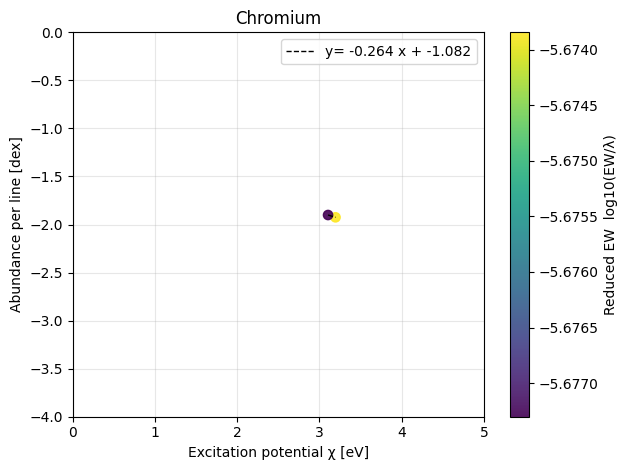

In [74]:
def func(x, a, b):
    return b + a*x

t2 = Table.read('samanta4500.out', format='ascii')

x   = np.array(t2['EP'], float)      # excitation potential [eV]
y   = np.array(t2['C'],  float)      # abundance [dex]
fe  = t2['elem']                     # species (numeric 26.0 or string 'Fe I')
wav = np.array(t2['wav'], float)     # wavelength [Å]
c2  = np.array(t2['c2'],  float)

# --- keep only Ni --- #22.1=Ti II, 21.1=Sc II, 25.0=Mn I, 12.0=Mg
try:
    mask = (fe == 24)
    if mask.sum() == 0:
        mask = (np.char.strip(fe.astype(str)) == 'Cr')
except Exception:
    mask = (np.char.strip(fe.astype(str)) == 'Cr')

x, y, wav, c2 = x[mask], y[mask], wav[mask], c2[mask]

# --- compute three diagnostics ---
# Option A: if c2 is reduced EW already (rare in your case)
rw_A = c2                                  # supposed log10(EW/λ)

# Option B: if c2 is log10(EW[mÅ])  --> reduced EW = c2 - 3 - log10(λ[Å])
rw_B = c2 - 3.0 - np.log10(wav)

# Actual EW in mÅ if c2 = log10(EW[mÅ])
EW_mA_from_c2 = 10.0**c2                   # only valid if c2 = log10(EW[mÅ])

# --- pick the sensible one for coloring ---
# Reduced EW should be around -6 .. -4 typically.
use_rw = rw_A if (-7 < np.nanmedian(rw_A) < -3) else rw_B
z = use_rw
cbar_label = "Reduced EW  log10(EW/λ)"

# --- mild sigma-clipping on y (abundance) ---
m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
m &= (y > np.nanmean(y)-2*np.nanstd(y)) & (y < np.nanmean(y)+2*np.nanstd(y))
x, y, z = x[m], y[m], z[m]

print("N lines:", len(x))
print("wav range [Å]:", np.nanmin(wav[m]), "→", np.nanmax(wav[m]))
print("Reduced EW range:", np.nanmin(z), "→", np.nanmax(z))

# --- plot with colorbar; tighten color range to show contrast if dynamic range is small ---
vmin, vmax = np.percentile(z, [5, 95]) if len(z) > 5 else (np.nanmin(z), np.nanmax(z))
sc = plt.scatter(x, y, c=z, cmap='viridis', s=45, alpha=0.9, norm=Normalize(vmin=vmin, vmax=vmax))
cbar = plt.colorbar(sc)
cbar.set_label(cbar_label)

# Fit
popt, _ = curve_fit(func, x, y, method='lm')
xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
plt.plot(xx, func(xx, *popt), 'k--', lw=1., label='y= %5.3f x + %5.3f' % tuple(popt))
plt.title("Chromium")
plt.axis([0, 5, -4, 0])
plt.xlabel("Excitation potential χ [eV]")
plt.ylabel("Abundance per line [dex]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

This is z
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False]
-1.5375 0.018500000000000072
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.1.1102230246251565e-16



/var/folders/6y/fwk8pnpn3l1_063t_xyj4ws80000gn/T/ipykernel_83000/4206424649.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, x, y, method='lm')


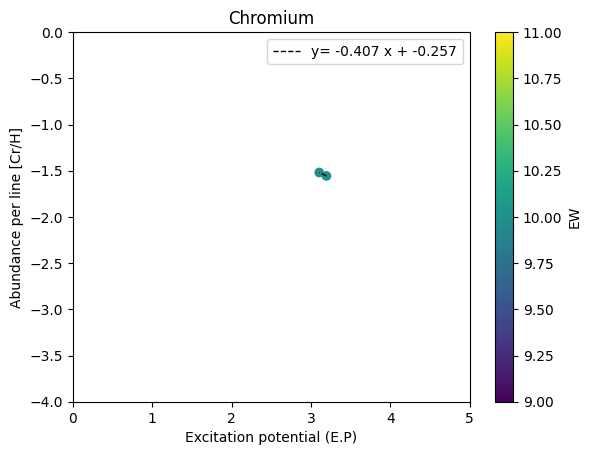

In [54]:
plt.figure()

t2 = Table.read('samanta5000.out', format='ascii')
print("This is z")
print(z)
x  = t2['EP']        # energia minima
y  = t2['C'] # abbondanza calcolata
#print(t2['wav'])
#print(fe)
fe = t2['elem']      # specie
#z  = 10**t2['c2']    # EW in mÅ (assumendo c2 = log10(EW[mÅ]))
print(z)
# --- Fe I + EW > 20 mÅ ---
limit = (fe == 24.0)
z = (10**t2['c2'])
print(z>20)
x = x[limit]

y = y[limit]
cvals = z[limit]
#cvals = cvals[limit]  # keep colors aligned with the same mask

print(np.mean(y), np.std(y))

# use EW as color
sc = plt.scatter(x, y, c=cvals, cmap='viridis')
cbar = plt.colorbar(sc)
cbar.set_label('EW')

popt, pcov = curve_fit(func, x, y, method='lm')
plt.plot(x, func(x, *popt), 'k--', lw=1.,
         label='y= %5.3f x + %5.3f' % tuple(popt))
std1 = np.std(y - func(x, *popt))
print(std1)
plt.title("Chromium")
plt.axis([0, 5, -4, 0])
plt.xlabel("Excitation potential (E.P)")
plt.ylabel("Abundance per line [Cr/H]")
plt.legend()
plt.show()

This is z
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False]
-1.913 0.01200000000000001
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
2.220446049250313e-16


/var/folders/6y/fwk8pnpn3l1_063t_xyj4ws80000gn/T/ipykernel_14192/2716529772.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, x, y, method='lm')


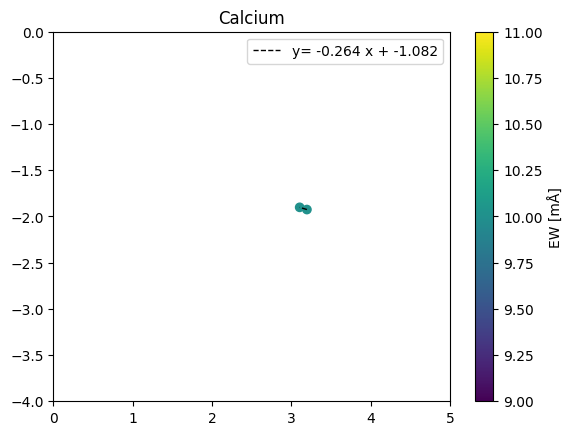

In [121]:
plt.figure()

t2 = Table.read('samanta4500.out', format='ascii')
print("This is z")
print(z)
x  = t2['EP']        # energia minima
y  = t2['C'] # abbondanza calcolata
#print(t2['wav'])
#print(fe)
fe = t2['elem']      # specie
#z  = 10**t2['c2']    # EW in mÅ (assumendo c2 = log10(EW[mÅ]))
print(z)
# --- Fe I + EW > 20 mÅ ---
limit = (fe == 24.0)
z = (10**t2['c2'])
print(z>20)
x = x[limit]

y = y[limit]
cvals = z[limit]
#cvals = cvals[limit]  # keep colors aligned with the same mask

print(np.mean(y), np.std(y))

# use EW as color
sc = plt.scatter(x, y, c=cvals, cmap='viridis')
cbar = plt.colorbar(sc)
cbar.set_label('EW [mÅ]')

popt, pcov = curve_fit(func, x, y, method='lm')
plt.plot(x, func(x, *popt), 'k--', lw=1.,
         label='y= %5.3f x + %5.3f' % tuple(popt))
std1 = np.std(y - func(x, *popt))
print(std1)
plt.title("Calcium")
plt.axis([0, 5, -4, 0])
plt.legend()
plt.show()

## Co

In [75]:
def func(x, a, b):
    return b + a*x

t2 = Table.read('samanta4500.out', format='ascii')

x   = np.array(t2['EP'], float)      # excitation potential [eV]
y   = np.array(t2['C'],  float)      # abundance [dex]
fe  = t2['elem']                     # species (numeric 26.0 or string 'Fe I')
wav = np.array(t2['wav'], float)     # wavelength [Å]
c2  = np.array(t2['c2'],  float)

# --- keep only Ni --- #22.1=Ti II, 21.1=Sc II, 25.0=Mn I, 12.0=Mg
try:
    mask = (fe == 27)
    if mask.sum() == 0:
        mask = (np.char.strip(fe.astype(str)) == 'Co')
except Exception:
    mask = (np.char.strip(fe.astype(str)) == 'Co')

x, y, wav, c2 = x[mask], y[mask], wav[mask], c2[mask]

# --- compute three diagnostics ---
# Option A: if c2 is reduced EW already (rare in your case)
rw_A = c2                                  # supposed log10(EW/λ)

# Option B: if c2 is log10(EW[mÅ])  --> reduced EW = c2 - 3 - log10(λ[Å])
rw_B = c2 - 3.0 - np.log10(wav)

# Actual EW in mÅ if c2 = log10(EW[mÅ])
EW_mA_from_c2 = 10.0**c2                   # only valid if c2 = log10(EW[mÅ])

# --- pick the sensible one for coloring ---
# Reduced EW should be around -6 .. -4 typically.
use_rw = rw_A if (-7 < np.nanmedian(rw_A) < -3) else rw_B
z = use_rw
cbar_label = "Reduced EW  log10(EW/λ)"

# --- mild sigma-clipping on y (abundance) ---
m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
m &= (y > np.nanmean(y)-2*np.nanstd(y)) & (y < np.nanmean(y)+2*np.nanstd(y))
x, y, z = x[m], y[m], z[m]

print("N lines:", len(x))
print("wav range [Å]:", np.nanmin(wav[m]), "→", np.nanmax(wav[m]))
print("Reduced EW range:", np.nanmin(z), "→", np.nanmax(z))

# --- plot with colorbar; tighten color range to show contrast if dynamic range is small ---
vmin, vmax = np.percentile(z, [5, 95]) if len(z) > 5 else (np.nanmin(z), np.nanmax(z))
sc = plt.scatter(x, y, c=z, cmap='viridis', s=45, alpha=0.9, norm=Normalize(vmin=vmin, vmax=vmax))
cbar = plt.colorbar(sc)
cbar.set_label(cbar_label)

# Fit
popt, _ = curve_fit(func, x, y, method='lm')
xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
plt.plot(xx, func(xx, *popt), 'k--', lw=1., label='y= %5.3f x + %5.3f' % tuple(popt))

plt.axis([0, 5, -4, 0])
plt.xlabel("Excitation potential χ [eV]")
plt.ylabel("Abundance per line [dex]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

N lines: 0


ValueError: zero-size array to reduction operation fmin which has no identity

This is z
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False]
-1.359 0.0


TypeError: Improper input: func input vector length N=2 must not exceed func output vector length M=1

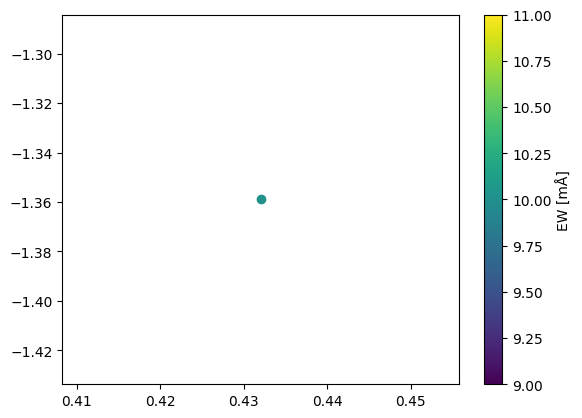

In [122]:
plt.figure()

t2 = Table.read('samanta4500.out', format='ascii')
print("This is z")
print(z)
x  = t2['EP']        # energia minima
y  = t2['C'] # abbondanza calcolata
#print(t2['wav'])
#print(fe)
fe = t2['elem']      # specie
#z  = 10**t2['c2']    # EW in mÅ (assumendo c2 = log10(EW[mÅ]))
print(z)
# --- Fe I + EW > 20 mÅ ---
limit = (fe == 27.0)
z = (10**t2['c2'])
print(z>20)
x = x[limit]

y = y[limit]
cvals = z[limit]
#cvals = cvals[limit]  # keep colors aligned with the same mask

print(np.mean(y), np.std(y))

# use EW as color
sc = plt.scatter(x, y, c=cvals, cmap='viridis')
cbar = plt.colorbar(sc)
cbar.set_label('EW [mÅ]')

popt, pcov = curve_fit(func, x, y, method='lm')
plt.plot(x, func(x, *popt), 'k--', lw=1.,
         label='y= %5.3f x + %5.3f' % tuple(popt))
std1 = np.std(y - func(x, *popt))
print(std1)
plt.title("Calcium")
plt.axis([0, 5, -4, 0])
plt.legend()
plt.show()

## Zn 30Zn

In [76]:
def func(x, a, b):
    return b + a*x

t2 = Table.read('samanta4500.out', format='ascii')

x   = np.array(t2['EP'], float)      # excitation potential [eV]
y   = np.array(t2['C'],  float)      # abundance [dex]
fe  = t2['elem']                     # species (numeric 26.0 or string 'Fe I')
wav = np.array(t2['wav'], float)     # wavelength [Å]
c2  = np.array(t2['c2'],  float)

# --- keep only Ni --- #22.1=Ti II, 21.1=Sc II, 25.0=Mn I, 12.0=Mg
try:
    mask = (fe == 30)
    if mask.sum() == 0:
        mask = (np.char.strip(fe.astype(str)) == 'Zn')
except Exception:
    mask = (np.char.strip(fe.astype(str)) == 'Zn')

x, y, wav, c2 = x[mask], y[mask], wav[mask], c2[mask]

# --- compute three diagnostics ---
# Option A: if c2 is reduced EW already (rare in your case)
rw_A = c2                                  # supposed log10(EW/λ)

# Option B: if c2 is log10(EW[mÅ])  --> reduced EW = c2 - 3 - log10(λ[Å])
rw_B = c2 - 3.0 - np.log10(wav)

# Actual EW in mÅ if c2 = log10(EW[mÅ])
EW_mA_from_c2 = 10.0**c2                   # only valid if c2 = log10(EW[mÅ])

# --- pick the sensible one for coloring ---
# Reduced EW should be around -6 .. -4 typically.
use_rw = rw_A if (-7 < np.nanmedian(rw_A) < -3) else rw_B
z = use_rw
cbar_label = "Reduced EW  log10(EW/λ)"

# --- mild sigma-clipping on y (abundance) ---
m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
m &= (y > np.nanmean(y)-2*np.nanstd(y)) & (y < np.nanmean(y)+2*np.nanstd(y))
x, y, z = x[m], y[m], z[m]

print("N lines:", len(x))
print("wav range [Å]:", np.nanmin(wav[m]), "→", np.nanmax(wav[m]))
print("Reduced EW range:", np.nanmin(z), "→", np.nanmax(z))

# --- plot with colorbar; tighten color range to show contrast if dynamic range is small ---
vmin, vmax = np.percentile(z, [5, 95]) if len(z) > 5 else (np.nanmin(z), np.nanmax(z))
sc = plt.scatter(x, y, c=z, cmap='viridis', s=45, alpha=0.9, norm=Normalize(vmin=vmin, vmax=vmax))
cbar = plt.colorbar(sc)
cbar.set_label(cbar_label)

# Fit
popt, _ = curve_fit(func, x, y, method='lm')
xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
plt.plot(xx, func(xx, *popt), 'k--', lw=1., label='y= %5.3f x + %5.3f' % tuple(popt))

plt.axis([0, 5, -4, 0])
plt.xlabel("Excitation potential χ [eV]")
plt.ylabel("Abundance per line [dex]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

N lines: 0


ValueError: zero-size array to reduction operation fmin which has no identity

This is z
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
 c2 
----
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
 ...
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
10.0
Length = 43 rows
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False]
-1.639 0.0


TypeError: Improper input: func input vector length N=2 must not exceed func output vector length M=1

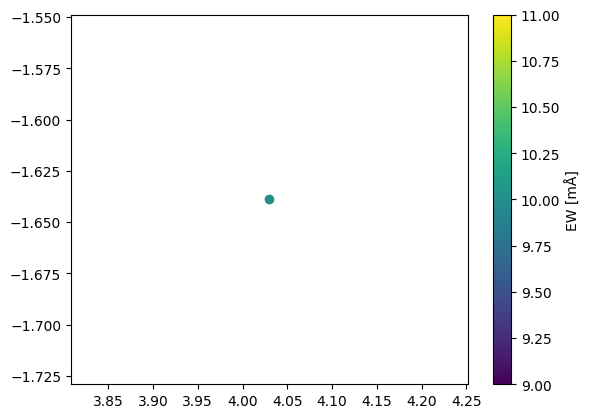

In [123]:
plt.figure()

t2 = Table.read('samanta4500.out', format='ascii')
print("This is z")
print(z)
x  = t2['EP']        # energia minima
y  = t2['C'] # abbondanza calcolata
#print(t2['wav'])
#print(fe)
fe = t2['elem']      # specie
#z  = 10**t2['c2']    # EW in mÅ (assumendo c2 = log10(EW[mÅ]))
print(z)
# --- Fe I + EW > 20 mÅ ---
limit = (fe == 30.0)
z = (10**t2['c2'])
print(z>20)
x = x[limit]

y = y[limit]
cvals = z[limit]
#cvals = cvals[limit]  # keep colors aligned with the same mask

print(np.mean(y), np.std(y))

# use EW as color
sc = plt.scatter(x, y, c=cvals, cmap='viridis')
cbar = plt.colorbar(sc)
cbar.set_label('EW [mÅ]')

popt, pcov = curve_fit(func, x, y, method='lm')
plt.plot(x, func(x, *popt), 'k--', lw=1.,
         label='y= %5.3f x + %5.3f' % tuple(popt))
std1 = np.std(y - func(x, *popt))
print(std1)
plt.title("Calcium")
plt.axis([0, 5, -4, 0])
plt.legend()
plt.show()